# Subsumption Recapitulation: Do LLM Embeddings Encode the Ontology Hierarchy?

LLM embeddings of ontology terms are built only from text (labels, and possibly
definitions). Ontologies encode **subsumption**: *finger syndactyly* is a kind of
*syndactyly*. This notebook asks how much of that hierarchy can be recovered from
embedding space.

We compare the four embedding models hosted by OLS with the ontology itself, written as
`closure` vectors (each term is a multi-hot vector of its ancestors). All comparisons use
the same `EmbeddingProviderInterface` code, so the only thing that changes between rows
is the source of the vectors.

**Design.** From the HPO phenotypic abnormality branch we sample:

- **parent pairs**: a term and one of its direct `is_a` parents
- **sibling pairs**: the same term and another child of that parent (not subsuming or
  subsumed); these are the hard negatives, because they are as close in the graph as a
  parent is
- **random pairs**: two terms drawn at random from the branch

We then ask two questions:

1. Does embedding similarity track ontology similarity (closure Jaccard)?
2. For each term, is its **parent** closer than a **sibling**? Cosine is symmetric, so
   this is the most that a single similarity score can say about subsumption; it cannot
   tell which term is the parent.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="eutils")
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import seaborn as sns

# reference palette (categorical slots in fixed order; sequential blue ramp)
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "font.size": 10, "axes.titlesize": 11, "figure.dpi": 110,
})
SEQUENTIAL = sns.blend_palette(["#f0efec", "#86b6ef", "#2a78d6", "#0d366b"], as_cmap=True)

In [2]:
import random
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from oaklib import get_adapter
from oaklib.datamodels.vocabulary import IS_A

hp = get_adapter("sqlite:obo:hp")
ols = get_adapter("ols:hp")
MODELS = ols.embedding_models()
PHENOTYPIC_ABNORMALITY = "HP:0000118"

## Sampling term pairs

In [3]:
random.seed(42)
terms = sorted(t for t in hp.descendants(PHENOTYPIC_ABNORMALITY, predicates=[IS_A], reflexive=False) if t.startswith("HP:"))

ancestors = {}
def anc(t):
    if t not in ancestors:
        ancestors[t] = set(hp.ancestors(t, predicates=[IS_A], reflexive=True)) - {"owl:Thing"}
    return ancestors[t]

parents, children = {}, defaultdict(list)
for s, _, o in hp.relationships(predicates=[IS_A]):
    if s.startswith("HP:") and o.startswith("HP:"):
        parents.setdefault(s, []).append(o)
        children[o].append(s)

candidates = [t for t in terms if t in parents]
random.shuffle(candidates)
triples = []
for c in candidates:
    p = random.choice(parents[c])
    if p in (PHENOTYPIC_ABNORMALITY, "HP:0000001"):
        continue
    siblings = [s for s in children[p] if s != c and s not in anc(c) and c not in anc(s)]
    if not siblings:
        continue
    triples.append((c, p, random.choice(siblings)))
    if len(triples) >= 150:
        break
random_pairs = [(random.choice(terms), random.choice(terms)) for _ in range(150)]

pairs = pd.DataFrame(
    [(c, p, "parent") for c, p, _ in triples]
    + [(c, s, "sibling") for c, _, s in triples]
    + [(a, b, "random") for a, b in random_pairs],
    columns=["subject", "object", "kind"],
)
all_terms = sorted(set(pairs.subject) | set(pairs.object))
print(f"{len(terms)} terms in branch; {len(triples)} (term, parent, sibling) triples; {len(all_terms)} distinct terms")
pairs.groupby("kind").size()

19177 terms in branch; 150 (term, parent, sibling) triples; 729 distinct terms


kind
parent     150
random     150
sibling    150
dtype: int64

## Vectors for every model

One matrix per model. OLS vectors are cached locally after the first run.

In [4]:
def pair_cosines(adapter, model, metric="cosine"):
    ids, m = adapter.entity_embeddings(all_terms, model=model)
    ix = {c: i for i, c in enumerate(ids)}
    if metric == "cosine":
        m = m / np.linalg.norm(m, axis=1, keepdims=True)
    out = []
    for s, o in zip(pairs.subject, pairs.object):
        if s not in ix or o not in ix:
            out.append(np.nan)
            continue
        a, b = m[ix[s]], m[ix[o]]
        if metric == "cosine":
            out.append(float(a @ b))
        else:
            a, b = a > 0, b > 0
            out.append((a & b).sum() / (a | b).sum())
    return out

pairs["closure_jaccard"] = pair_cosines(hp, "closure", metric="jaccard")
pairs["closure"] = pair_cosines(hp, "closure")
for model in MODELS:
    pairs[model] = pair_cosines(ols, model)
SOURCES = ["closure"] + MODELS
pairs.head()

,subject,object,kind,closure_jaccard,closure,harrier-oss-v1-27b_pca512,llama-embed-nemotron-8b_pca512,text-embedding-3-large_pca512,text-embedding-3-small_pca512
0,HP:0012712,HP:0000365,parent,0.857143,0.925820,0.826311,0.739575,0.838928,0.819596
1,HP:0100623,HP:0000036,parent,0.900000,0.948683,0.864599,0.876593,0.779589,0.792845
2,HP:0002343,HP:0000238,parent,0.900000,0.948683,0.831912,0.721223,0.837716,0.790062
3,HP:6000651,HP:0010660,parent,0.684211,0.827170,0.930526,0.855038,0.900561,0.873528
4,HP:0033265,HP:0031265,parent,0.923077,0.960769,0.717179,0.471363,0.636514,0.522678


## 1. Does embedding similarity track ontology similarity?

Each point is a pair of terms. The x-axis is the Jaccard similarity of the two terms'
ancestor sets (classic semantic similarity), and the y-axis is cosine similarity in each
model's embedding space.

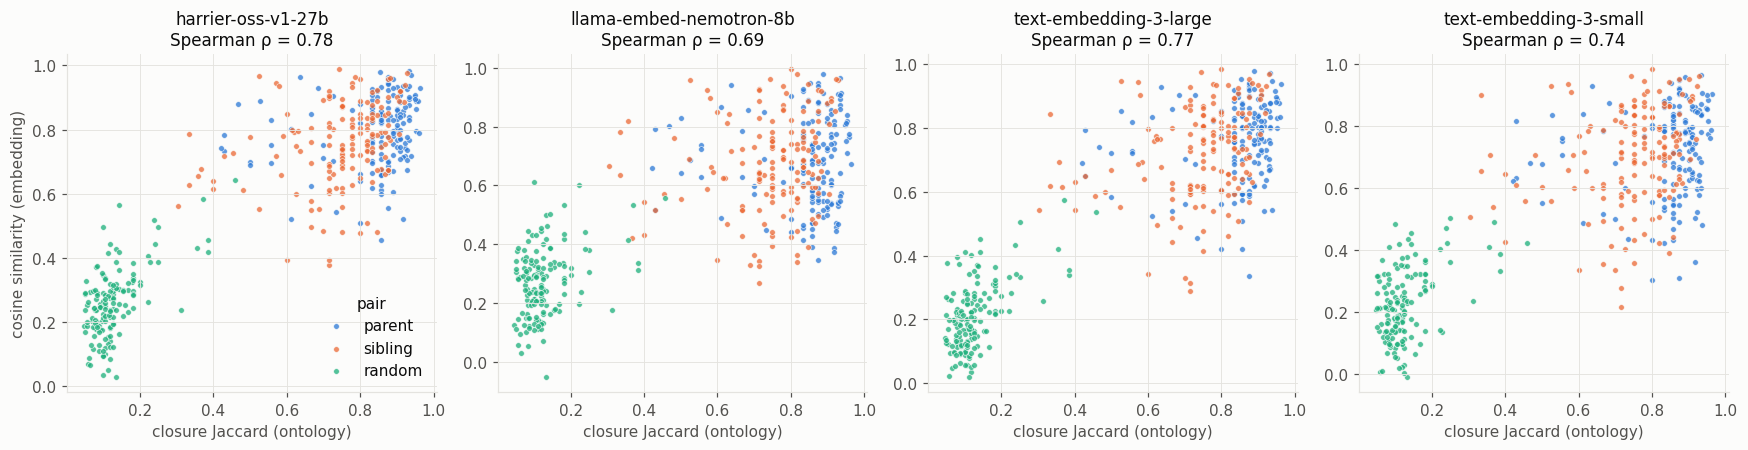

In [5]:
KIND_COLORS = {"parent": BLUE, "sibling": ORANGE, "random": AQUA}
fig, axes = plt.subplots(1, len(MODELS), figsize=(16, 4.2), sharex=True)
for ax, model in zip(axes, MODELS):
    for kind, color in KIND_COLORS.items():
        d = pairs[pairs.kind == kind]
        ax.scatter(d.closure_jaccard, d[model], s=14, color=color, alpha=0.75,
                   edgecolors=SURFACE, linewidths=0.5, label=kind)
    rho = spearmanr(pairs.closure_jaccard, pairs[model], nan_policy="omit").statistic
    ax.set_title(f"{model.replace('_pca512', '')}\nSpearman ρ = {rho:.2f}")
    ax.set_xlabel("closure Jaccard (ontology)")
axes[0].set_ylabel("cosine similarity (embedding)")
axes[0].legend(title="pair", frameon=False, loc="lower right")
fig.tight_layout()

In [6]:
corr = pd.DataFrame({
    "Spearman ρ, all pairs": [spearmanr(pairs.closure_jaccard, pairs[m], nan_policy="omit").statistic for m in SOURCES],
    "Spearman ρ, parent + sibling only": [
        spearmanr(*pairs.loc[pairs.kind != "random", ["closure_jaccard", m]].T.values, nan_policy="omit").statistic
        for m in SOURCES
    ],
}, index=SOURCES)
corr.round(3)

,"Spearman ρ, all pairs","Spearman ρ, parent + sibling only"
closure,0.999,0.999
harrier-oss-v1-27b_pca512,0.775,0.313
llama-embed-nemotron-8b_pca512,0.687,0.108
text-embedding-3-large_pca512,0.768,0.297
text-embedding-3-small_pca512,0.739,0.230


All four LLM models correlate well with ontology similarity when random pairs are
included (ρ ≈ 0.7 to 0.8), because unrelated terms are easy to separate. Among closely
related terms (parents and siblings only) the correlation falls to ρ ≈ 0.1 to 0.3: in text
space, the fine structure of the hierarchy is largely invisible. In the scatter plots,
parent pairs (blue) and sibling pairs (orange) overlap almost completely on the y-axis,
even though the ontology separates them on the x-axis. (The `closure` row is a sanity
check: cosine and Jaccard over the same binary vectors are nearly monotonic.)

## 2. Is a term's parent closer than its sibling?

For each sampled term, we check whether cosine(term, parent) > cosine(term, sibling).
Chance is 50%.

,parent closer than sibling,95% CI low,95% CI high
source,,,
closure,0.987,0.953,0.996
harrier-oss-v1-27b_pca512,0.620,0.540,0.694
llama-embed-nemotron-8b_pca512,0.447,0.369,0.527
text-embedding-3-large_pca512,0.587,0.507,0.662
text-embedding-3-small_pca512,0.493,0.414,0.573


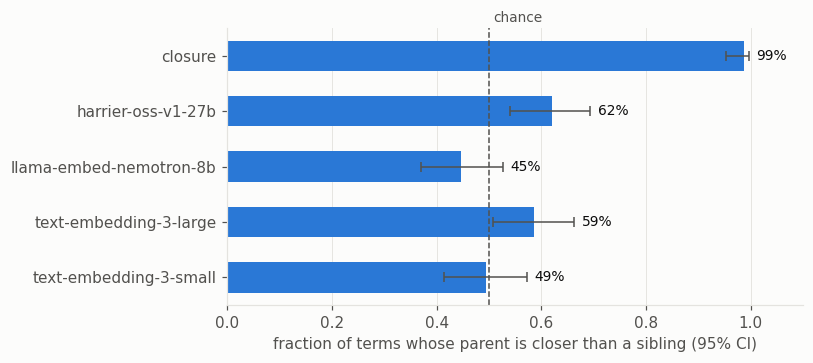

In [7]:
par = pairs[pairs.kind == "parent"].reset_index(drop=True)
sib = pairs[pairs.kind == "sibling"].reset_index(drop=True)

def wilson(k, n, z=1.96):
    # 95% Wilson score interval for a proportion
    p = k / n
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return centre - half, centre + half

rows = []
for m in SOURCES:
    k, n = int((par[m] > sib[m]).sum()), len(par)
    lo, hi = wilson(k, n)
    rows.append({"source": m, "parent closer than sibling": k / n, "95% CI low": lo, "95% CI high": hi})
wins = pd.DataFrame(rows).set_index("source")

fig, ax = plt.subplots(figsize=(7.5, 3.4))
names = [m.replace("_pca512", "") for m in SOURCES]
v = wins["parent closer than sibling"].values
err = [v - wins["95% CI low"].values, wins["95% CI high"].values - v]
ax.set_axisbelow(True)
ax.barh(names, v, color=BLUE, height=0.55, xerr=err, error_kw={"ecolor": INK2, "elinewidth": 1, "capsize": 3})
ax.axvline(0.5, color=INK2, linewidth=1, linestyle="--")
ax.annotate("chance", (0.5, 1.0), xycoords=("data", "axes fraction"), xytext=(3, 2),
            textcoords="offset points", color=INK2, fontsize=9, va="bottom")
for y, (val, hi) in enumerate(zip(v, wins["95% CI high"].values)):
    ax.text(hi + 0.015, y, f"{val:.0%}", va="center", color=INK, fontsize=9)
ax.set_xlim(0, 1.1)
ax.set_xlabel("fraction of terms whose parent is closer than a sibling (95% CI)")
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
fig.tight_layout()
wins.round(3)

## Where the models get it wrong

The cases where a model places a sibling closer than the parent show the kinds of
structure that text similarity misses: siblings that share most of their wording, and
parents with generic labels.

In [8]:
model = "text-embedding-3-large_pca512"
miss = par[par[model] <= sib[model]].copy()
miss["sibling"] = sib.loc[miss.index, "object"]
miss["cos(term, parent)"] = miss[model]
miss["cos(term, sibling)"] = sib.loc[miss.index, model]
lbl = dict(hp.labels(set(miss.subject) | set(miss.object) | set(miss.sibling)))
miss = miss.assign(term=miss.subject.map(lbl), parent=miss.object.map(lbl), sibling=miss.sibling.map(lbl))
miss[["term", "parent", "sibling", "cos(term, parent)", "cos(term, sibling)"]].head(10).round(3)

,term,parent,sibling,"cos(term, parent)","cos(term, sibling)"
4,Podocyte myelin figures,Abnormal glomerular visceral epithelial cell m...,Podocyte foot process effacement,0.637,0.687
6,Jumping,Stereotypic whole-body movements,Stereotypical body rocking,0.455,0.490
8,Excessive purine production,Abnormal homeostasis,Abnormal glucose homeostasis,0.421,0.443
10,Upper eyelid erythema,Eyelid erythema,Lower eyelid erythema,0.916,0.933
14,Increased circulating interleukin 8 concentration,Abnormal circulating interleukin concentration,Increased circulating interleukin 13 concentra...,0.713,0.725
17,Decreased circulating alkaline phosphatase act...,Abnormality of alkaline phosphatase level,Elevated circulating alkaline phosphatase conc...,0.862,0.866
18,Best corrected visual acuity 0.9 LogMAR,Abnormal best corrected visual acuity test,Best corrected visual acuity 3.0 LogMAR,0.753,0.932
20,Intrathoracic hemangioma,Hemangioma,Visceral hemangioma,0.753,0.797
23,Philtrum with midline raphe,Abnormality of the philtrum,Short philtrum,0.616,0.725
24,Triceps areflexia,Areflexia of upper limbs,Biceps areflexia,0.803,0.908


## Summary

- **Coarse structure: yes.** All four OLS-hosted LLM embedding models separate related
  from unrelated HPO terms well.
- **Fine structure: barely.** Given a term, its direct parent is not reliably closer than a
  sibling. The best models (harrier, text-embedding-3-large) are only modestly above
  chance, and nemotron and text-embedding-3-small are at chance. The ontology closure gets
  this right 99% of the time (the misses involve terms with several parents).
- **Direction: no.** Cosine similarity is symmetric, so embeddings alone cannot say
  which of two terms subsumes the other. That needs the ontology, or an asymmetric scoring
  method such as a trained entailment classifier.

In practice, LLM embeddings are useful for finding the right neighbourhood (search,
grounding, candidate mappings), but they should not stand in for the hierarchy when exact
subsumption matters.

**Caveats.** 150 triples per condition gives 95% intervals of about ±8 percentage points,
so differences between the LLM models are indicative only. OLS embeds a fixed text per
class (see [#918](https://github.com/INCATools/ontology-access-kit/issues/918)), and
embedding labels plus definitions may behave differently; the `llm:` adapter can test that.
Increase the sample size in the sampling cell to tighten the estimates. Vectors are cached,
so only new terms are fetched from OLS.